# Demographics and SAT Scores

Higher education is something all people should want and be able to achieve, regardless of whether it is motivated by professional or personal growth. However, many institutes of higher education use, among other things, the [Scholastic Aptitude Test](https://blog.prepscholar.com/what-is-the-sat-a-complete-explanation-of-the-test), or SAT, score to determine eligibility. In theory this allows schools to be more selective of the students that it admits on basis of probability of academic success. Practically, however, SAT scores may be influenced by external factors that are unrelated to a student's intelligence or academic capacity. 

New York City has published SAT scores and demographic data across its schools. As New York City is a very diverse area, that data could show some indication of demographic inequity with regards to SAT scores. 

# Data: What are we working with? 

This data has all been provided by New York City about all of their schools' demographics and SAT scores. 
- [SAT scores by school](https://data.cityofnewyork.us/Education/SAT-Results/f9bf-2cp4): SAT scores for each high school in New York City
- [School attendance](https://data.cityofnewyork.us/Education/School-Attendance-and-Enrollment-Statistics-by-Dis/7z8d-msnt): Attendance information for each school in New York City
- [Class size](https://data.cityofnewyork.us/Education/2010-2011-Class-Size-School-level-detail/urz7-pzb3): Information on class size for each school
- [AP test results](https://data.cityofnewyork.us/Education/AP-College-Board-2010-School-Level-Results/itfs-ms3e): Advanced Placement (AP) exam results for each high school (passing an optional AP exam in a particular subject can earn a student college credit in that subject)
- [Graduation outcomes](https://data.cityofnewyork.us/Education/Graduation-Outcomes-Classes-Of-2005-2010-School-Le/vh2h-md7a): The percentage of students who graduated, and other outcome information
- [Demographics](https://data.cityofnewyork.us/Education/School-Demographics-and-Accountability-Snapshot-20/ihfw-zy9j): Demographic information for each school
- [School survey](https://data.cityofnewyork.us/Education/NYC-School-Survey-2011/mnz3-dyi8): Surveys of parents, teachers, and students at each school

# Read in the data

In [27]:
import pandas as pd
import numpy
import re

data_files = [
    "ap_2010.csv",
    "class_size.csv",
    "demographics.csv",
    "graduation.csv",
    "hs_directory.csv",
    "sat_results.csv"
]
data = {}

for f in data_files:
    key_name = f.replace(".csv", "")
    d = pd.read_csv(f"schools/{f}")
    data[key_name] = d

# Read in the surveys

Surveys are in txt files with different encodings. We are going to read them and save in data dictionary. There are about 2000 columns that we do not need most of them. First, we'll need to make the name of 'dbn' column uppercase and then filter the columns to remove the ones we don't need. The list of relevant columns will be saved in suervey_fields.

In [28]:
all_survey = pd.read_csv("schools/survey_all.txt", delimiter="\t", encoding='windows-1252')
d75_survey = pd.read_csv("schools/survey_d75.txt", delimiter="\t", encoding='windows-1252')
survey = pd.concat([all_survey, d75_survey], axis=0)

survey = survey.copy()
survey["DBN"] = survey["dbn"]

survey_fields = [
    "DBN", 
    "rr_s", 
    "rr_t", 
    "rr_p", 
    "N_s", 
    "N_t", 
    "N_p", 
    "saf_p_11", 
    "com_p_11", 
    "eng_p_11", 
    "aca_p_11", 
    "saf_t_11", 
    "com_t_11", 
    "eng_t_11", 
    "aca_t_11", 
    "saf_s_11", 
    "com_s_11", 
    "eng_s_11", 
    "aca_s_11", 
    "saf_tot_11", 
    "com_tot_11", 
    "eng_tot_11", 
    "aca_tot_11",
]
survey = survey[survey_fields]
data["survey"] = survey

# Add DBN columns

In [29]:
data["hs_directory"]["DBN"] = data["hs_directory"]["dbn"]

def pad_csd(num):
    string_representation = str(num)
    if len(string_representation) > 1:
        return string_representation
    else:
        return "0" + string_representation
    
data["class_size"]["padded_csd"] = data["class_size"]["CSD"].apply(pad_csd)
data["class_size"]["DBN"] = data["class_size"]["padded_csd"] + data["class_size"]["SCHOOL CODE"]

The other needed column is the column that totals up the SAT scores for the different sections of the exam. This will make it much easier to correlate scores with demographic factors because we'll be working with a single number, rather than three different ones.

Next, we are going to extract the latitude and longitude from "Location 1" column for each school and save them in different columns.

# Convert columns to numeric

In [30]:
cols = ['SAT Math Avg. Score', 'SAT Critical Reading Avg. Score', 'SAT Writing Avg. Score']
for c in cols:
    data["sat_results"][c] = pd.to_numeric(data["sat_results"][c], errors="coerce")

data['sat_results']['sat_score'] = data['sat_results'][cols[0]] + data['sat_results'][cols[1]] + data['sat_results'][cols[2]]

def find_lat(loc):
    coords = re.findall("\(.+, .+\)", loc)
    lat = coords[0].split(",")[0].replace("(", "")
    return lat

def find_lon(loc):
    coords = re.findall("\(.+, .+\)", loc)
    lon = coords[0].split(",")[1].replace(")", "").strip()
    return lon

data["hs_directory"]["lat"] = data["hs_directory"]["Location 1"].apply(find_lat)
data["hs_directory"]["lon"] = data["hs_directory"]["Location 1"].apply(find_lon)

data["hs_directory"]["lat"] = pd.to_numeric(data["hs_directory"]["lat"], errors="coerce")
data["hs_directory"]["lon"] = pd.to_numeric(data["hs_directory"]["lon"], errors="coerce")

# Condense datasets

For combining the dataframes in the data, DBN should be unique in all of them. we noticed that the values in the DBN column were unique in the sat_results data set, but Other data sets like class_size had duplicate DBN values, however.

We'll need to condense these data sets so that each value in the DBN column is unique. If not, we'll run into issues when it comes time to combine the data sets. To resolve this issue, we'll condense the following data sets:

* class_size
* demographics
* graduation
## class_size:
For condensing the class_size we need to do the following:

* Because we're dealing with high school, we only want to pick rows where the value in the GRADE column is 09-12.
* Looking at the unique values for PROGRAM TYPE, we get GEN ED is the largest category, so let's only select rows where PROGRAM TYPE is GEN ED.
* After these two filterings, DBN is not still unique and it seems it is because of different courses for each row so we are going to group by DBN and make average on the other columns.
## demographics: 
For condensing demographics we will select the rows where schoolyear is 20112012.

## graduation 
The Demographic and Cohort columns are what prevent DBN from being unique in the graduation data. A Cohort appears to refer to the year the data represents, and the Demographic appears to refer to a specific demographic group. In this case, we want to pick data from the most recent Cohort available, which is 2006. We also want data from the full cohort, so we'll only pick rows where Demographic is Total Cohort.

In [31]:
class_size = data["class_size"]
class_size = class_size[class_size["GRADE "] == "09-12"]
class_size = class_size[class_size["PROGRAM TYPE"] == "GEN ED"]

class_size = class_size.groupby("DBN").agg('mean', numeric_only=True)
class_size.reset_index(inplace=True)
data["class_size"] = class_size

data["demographics"] = data["demographics"][data["demographics"]["schoolyear"] == 20112012]

data["graduation"] = data["graduation"][data["graduation"]["Cohort"] == "2006"]
data["graduation"] = data["graduation"][data["graduation"]["Demographic"] == "Total Cohort"]

# Convert AP scores to numeric

In [32]:
cols = ['AP Test Takers ', 'Total Exams Taken', 'Number of Exams with scores 3 4 or 5']

for col in cols:
    data["ap_2010"][col] = pd.to_numeric(data["ap_2010"][col], errors="coerce")

# Combine the datasets

After cleaning data it is the time to merge all the data sets. Our strategy is summarized below:

-DBN is the column we use to merge based on.

* Since we are going to correlate the demographic factors with SAT score, we will want to preserve as many rows as possible from SAT score while minimizing null values.
* Some of the data sets have a lot of missing DBN values. This makes a left join more appropriate because we don't want to lose too many rows when we merge.
* Some data sets have DBN values that are almost identical to those in sat_results. Inner join is the proper option for these data sets

So we are going to merge the data sets with this plan:

* Both the ap_2010 and the graduation data sets have many missing DBN values, so we'll use a left join
* Because class_size, demographics, survey, and hs_directory contain information that's more valuable to our analysis and also have fewer missing DBN values, we'll use the inner join type.
* After merging we will fill all null values with the mean value of that column. If all values in a column is null, we will fill it with 0.

In [33]:
combined = data["sat_results"]

combined = combined.merge(data["ap_2010"], on="DBN", how="left")
combined = combined.merge(data["graduation"], on="DBN", how="left")

to_merge = ["class_size", "demographics", "survey", "hs_directory"]

for m in to_merge:
    combined = combined.merge(data[m], on="DBN", how="inner")

combined = combined.fillna(combined.mean(numeric_only=True))
combined = combined.infer_objects(copy=False).fillna(0)

# Add a school district column for mapping

In [34]:
def get_first_two_chars(dbn):
    return dbn[0:2]

combined = combined.copy()
combined["school_dist"] = combined["DBN"].apply(get_first_two_chars)

# Find correlations

In [35]:
correlations = combined.corr(numeric_only=True)
correlations = correlations["sat_score"]
print(correlations)

SAT Critical Reading Avg. Score    0.986820
SAT Math Avg. Score                0.972643
SAT Writing Avg. Score             0.987771
sat_score                          1.000000
AP Test Takers                     0.523140
                                     ...   
priority08                              NaN
priority09                              NaN
priority10                              NaN
lat                               -0.121029
lon                               -0.132222
Name: sat_score, Length: 67, dtype: float64


In general, r values above .25 or below -.25 are enough to qualify a correlation as interesting. These are the columns that show correlation with sat score:

* total_enrolment has a positive correlation with sat_score so smaller schools where students receive more attention do not have higher scores.
* Other columns like total_students, N_s, N_p, N_t, AP Test Takers, Total Exams Taken, and NUMBER OF SECTIONS, that are proxies for enrollment correlate with sat_score. The correlation confirms that larger schools do better on the SAT.
* female_per and female_num correlate positively with SAT score, whereas male_per and male_num correlate negatively. This could indicate that women do better than men.
* Teacher and student ratings of school safety (saf_t_11, and saf_s_11) correlate positively with sat_score.
* Student ratings of school academic standards (aca_s_11) correlate positively with sat_score, but this does not hold for ratings from teachers and parents (aca_p_11 and aca_t_11).
* There is significant racial inequality in SAT scores (white_per, asian_per, black_per, hispanic_per).
* The percentage of English language learners at the school (ell_percent, frl_percent) has a strong negative correlation with SAT scores.

We are going to draw some scatter plots to figure out if the correlation really exists.

# Plotting survey correlations

In [36]:
# Remove DBN since it's a unique identifier, not a useful numerical value for correlation.
survey_fields.remove("DBN")

<Axes: >

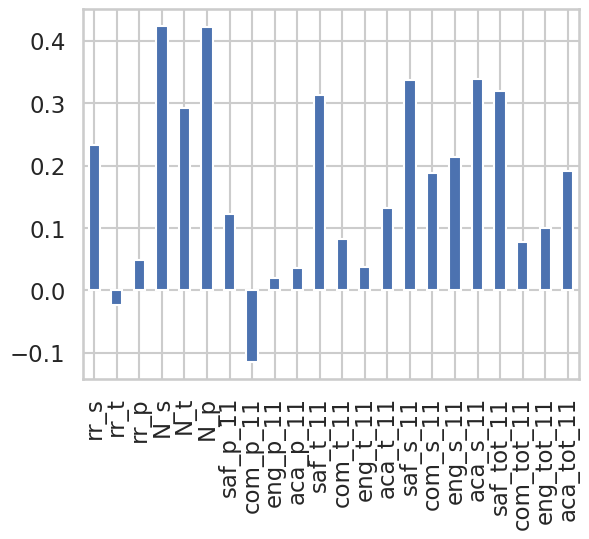

In [37]:
%matplotlib inline
combined.corr(numeric_only=True)['sat_score'][survey_fields].plot.bar()

There are high correlations between N_s, N_t, N_p, and sat_score. Since these columns are correlated with total_enrollment, it makes sense that they would be high.

It is more interesting that rr_s, the student response rate, or the percentage of students that completed the survey, correlates with sat_score. This might make sense because students who are more likely to fill out surveys may be more likely to also be doing well academically.

How students and teachers percieved safety (saf_t_11 and saf_s_11) correlate with sat_score. This make sense — it's difficult to teach or learn in an unsafe environment.

The last interesting correlation is the aca_s_11, which indicates how the student perceives academic standards, correlates with sat_score, but this is not true for aca_t_11, how teachers perceive academic standards, or aca_p_11, how parents perceive academic standards.

# Exploring Safety

<Axes: xlabel='sat_score', ylabel='saf_s_11'>

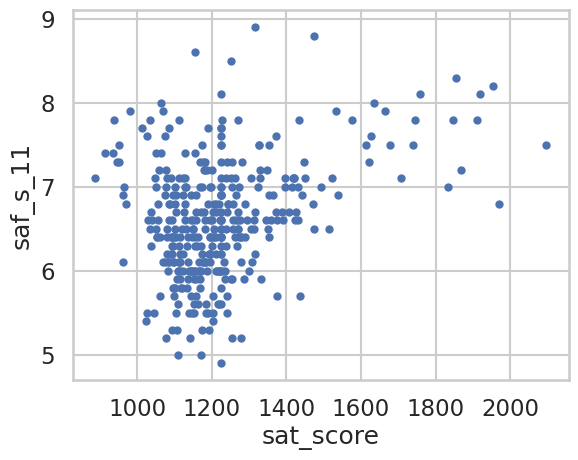

In [38]:
combined.plot.scatter("sat_score", "saf_s_11")

There appears to be a correlation between SAT scores and safety, although it isn't very strong. It looks like there are a few schools with extremely high SAT scores and high safety scores. There are a few schools with low safety scores and low SAT scores. No school with a safety score lower than 6.5 has an average SAT score higher than 1500 or so.

Text(0, 0.5, 'Teacher Safety')

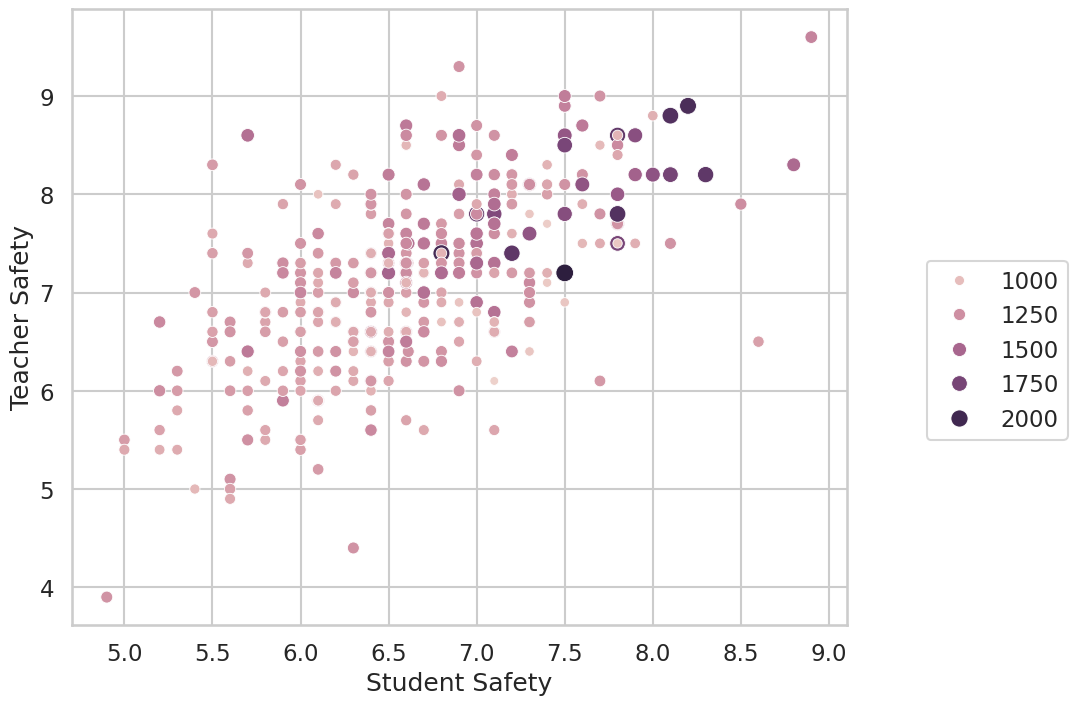

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='talk')
plt.figure(figsize=(10,8))
sns.scatterplot(x='saf_s_11', y='saf_t_11', size='sat_score', hue='sat_score', data=combined)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, .61));
plt.xlabel('Student Safety')
plt.ylabel('Teacher Safety')

It seems like the safety of both students and teachers correlate similarly to SAT score, and where both are good, the scores are better, but there are some obvious exceptions (the point with highest student *and* teacher safety scored only within the 1200 range).

# Borough Safety

In [40]:
boros = combined.groupby("boro").agg('mean', numeric_only=True)["saf_s_11"]
print(boros)

boro
Bronx            6.606577
Brooklyn         6.370755
Manhattan        6.831370
Queens           6.721875
Staten Island    6.530000
Name: saf_s_11, dtype: float64


It looks like Manhattan and Queens tend to have higher safety scores, whereas Brooklyn has low safety scores.

# Racial Differences in SAT Scores

<Axes: >

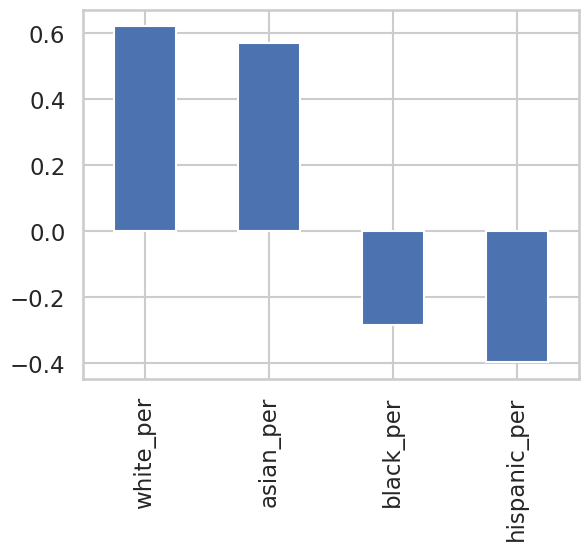

In [41]:
race_fields = ["white_per", "asian_per", "black_per", "hispanic_per"]

combined.corr(numeric_only=True)["sat_score"][race_fields].plot.bar()

It looks like a higher percentage of white or Asian students at a school correlates positively with SAT scores, whereas a higher percentage of black or Hispanic students correlates negatively with SAT score. This may be due to a lack of funding for schools in certain areas, which are more likely to have a higher percentage of black or Hispanic students.

Text(0.5, 1.0, 'SAT score Hispanic percent')

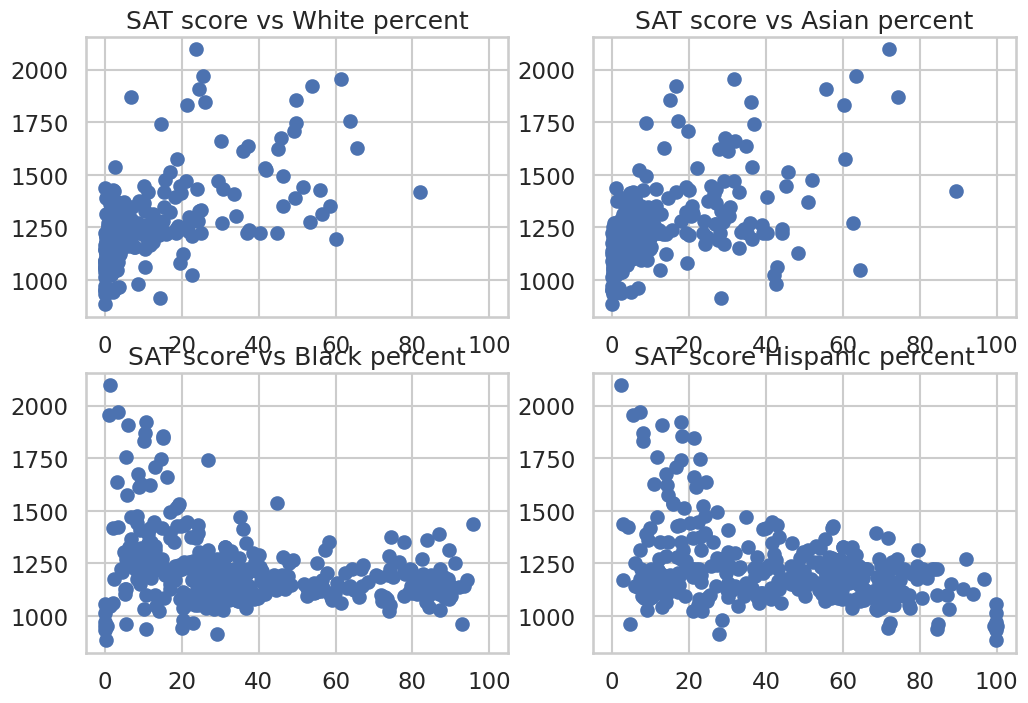

In [42]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

ax1.scatter(combined['white_per'], combined['sat_score'])
ax1.set_xlim(-5, 105)
ax1.set_title('SAT score vs White percent')
ax2.scatter(combined['asian_per'], combined['sat_score'])
ax2.set_xlim(-5, 105)
ax2.set_title('SAT score vs Asian percent')
ax3.scatter(combined['black_per'], combined['sat_score'])
ax3.set_xlim(-5, 105)
ax3.set_title('SAT score vs Black percent')
ax4.scatter(combined['hispanic_per'], combined['sat_score'])
ax4.set_xlim(-5, 105)
ax4.set_title('SAT score Hispanic percent')

Looking at the above plots, Hispanic percent shows a stronger relationship with the sat score. The plot shows that increasing the number of Hispanic students results in decreasing the SAT score. Let's research about the schools with a hispanic_per greater than 95% and find their names.

In [43]:
print(combined[combined["hispanic_per"] > 95]["SCHOOL NAME"])

44                         MANHATTAN BRIDGES HIGH SCHOOL
82      WASHINGTON HEIGHTS EXPEDITIONARY LEARNING SCHOOL
89     GREGORIO LUPERON HIGH SCHOOL FOR SCIENCE AND M...
125                  ACADEMY FOR LANGUAGE AND TECHNOLOGY
141                INTERNATIONAL SCHOOL FOR LIBERAL ARTS
176     PAN AMERICAN INTERNATIONAL HIGH SCHOOL AT MONROE
253                            MULTICULTURAL HIGH SCHOOL
286               PAN AMERICAN INTERNATIONAL HIGH SCHOOL
Name: SCHOOL NAME, dtype: object


The schools listed above appear to primarily serve recent immigrants to the U.S. These schools have many students who are learning English, which would explain the lower SAT scores.

In [44]:
print(combined[(combined["hispanic_per"] < 10) & (combined["sat_score"] > 1800)]["SCHOOL NAME"])

37                                STUYVESANT HIGH SCHOOL
151                         BRONX HIGH SCHOOL OF SCIENCE
187                       BROOKLYN TECHNICAL HIGH SCHOOL
327    QUEENS HIGH SCHOOL FOR THE SCIENCES AT YORK CO...
356                  STATEN ISLAND TECHNICAL HIGH SCHOOL
Name: SCHOOL NAME, dtype: object


Many of the schools above appear to be specialized science and technology schools that receive extra funding and only admit students who pass an entrance exam. This doesn't explain the low hispanic_per, but it does explain why their students tend to do better on the SAT — they are students from all over New York City who did well on a standardized test.

# Gender Differences in SAT Scores

<Axes: >

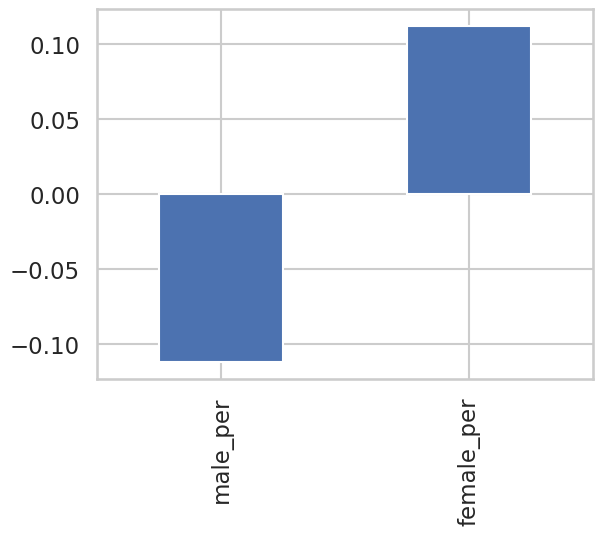

In [45]:
gender_fields = ["male_per", "female_per"]
combined.corr(numeric_only=True)["sat_score"][gender_fields].plot.bar()

In the plot above, we can see that a high percentage of females at a school positively correlates with SAT scores, whereas a high percentage of males at a school negatively correlates with SAT scores. Neither correlation is extremely strong.

<Axes: xlabel='female_per', ylabel='sat_score'>

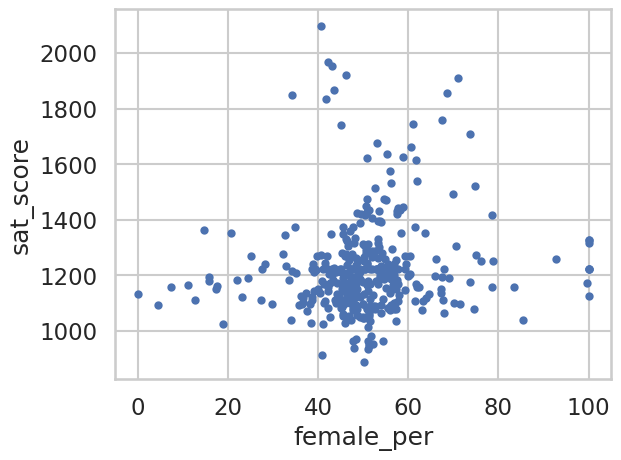

In [46]:
combined.plot.scatter("female_per", "sat_score")

Based on the scatter plot, there doesn't seem to be any real correlation between sat_score and female_per. However, there is a cluster of schools with a high percentage of females (60 to 80) and high SAT scores.

In [47]:
print(combined[(combined["female_per"] > 60) & (combined["sat_score"] > 1700)]["SCHOOL NAME"])

5                         BARD HIGH SCHOOL EARLY COLLEGE
26                         ELEANOR ROOSEVELT HIGH SCHOOL
60                                    BEACON HIGH SCHOOL
61     FIORELLO H. LAGUARDIA HIGH SCHOOL OF MUSIC & A...
302                          TOWNSEND HARRIS HIGH SCHOOL
Name: SCHOOL NAME, dtype: object


These schools appear to be very selective liberal arts schools that have high academic standards.

# AP Exam Scores vs. SAT Scores

<Axes: xlabel='ap_per', ylabel='sat_score'>

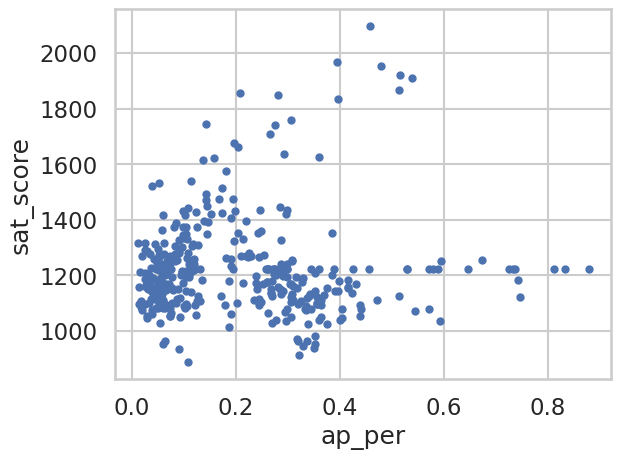

In [48]:
combined["ap_per"] = combined["AP Test Takers "] / combined["total_enrollment"]
combined = combined.copy()
combined.plot.scatter(x='ap_per', y='sat_score')

It looks like there is a relationship between the percentage of students in a school who take the AP exam and their average SAT scores. It's not a very strong correlation, however.

# English as a Second Language
 The barrier of entry to academia in foreign countries vary, regardless of linguistic prowess, but there appears to be a distinct difficulty of schools with higher percentages of ESL students to place higher in average SAT scores.

<Axes: xlabel='sat_score', ylabel='ell_percent'>

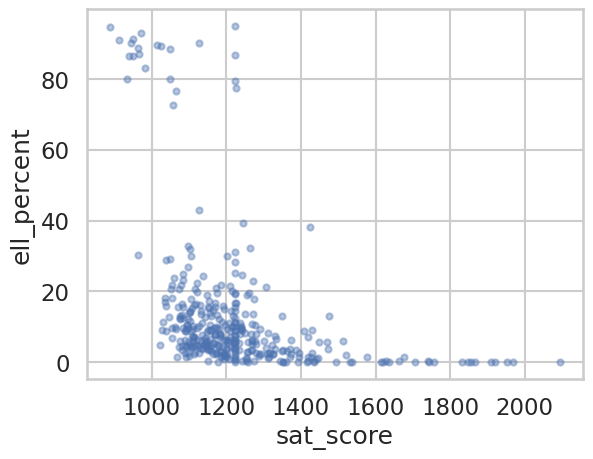

In [49]:
combined.plot.scatter(x='sat_score', y='ell_percent', alpha=.4)

While the divide is clear, schools who have a higher percentage of ESL students tend to have lower SAT scores on average, the reasoning behind that is not. Perhaps the SAT is unfavorable to those whose English language skills are not very strong (reasonable, since a large portion (two-thirds) of the SAT is based on English comprehension). Perhaps also those schools with higher-than-average ESL students also have lower budgets and therefore less financial freedom to help educate their students in preparation for standardized testing, due to their already greater fiscal strain of across-the-board ESL classes.

# The Inequity of Poverty
The strongest correlations so far have been these:
- Smaller schools do slightly worse overall
- Larger number of ESL students means worse scores on average
- Black and Hispanic populaces typically suffer from worse scores, but the schools with higher black/hispanic populations and lower scores had high rates of poverty.
- A feeling of safety has a somewhat positive correlation with SAT scores
- Higher number of AP test takers means higher SAT scores.

Most of these, with the exception of safety (where the average student safety was relatively unimpacted by surrounding poverty levels), are directly correlated to poverty issues. To take a closer look at this, we'll examine the percentage of students receiving free or reduced-cost lunches.

Text(0, 0.5, 'Percentage of Students Receiving Reduced-Cost/Free Lunch')

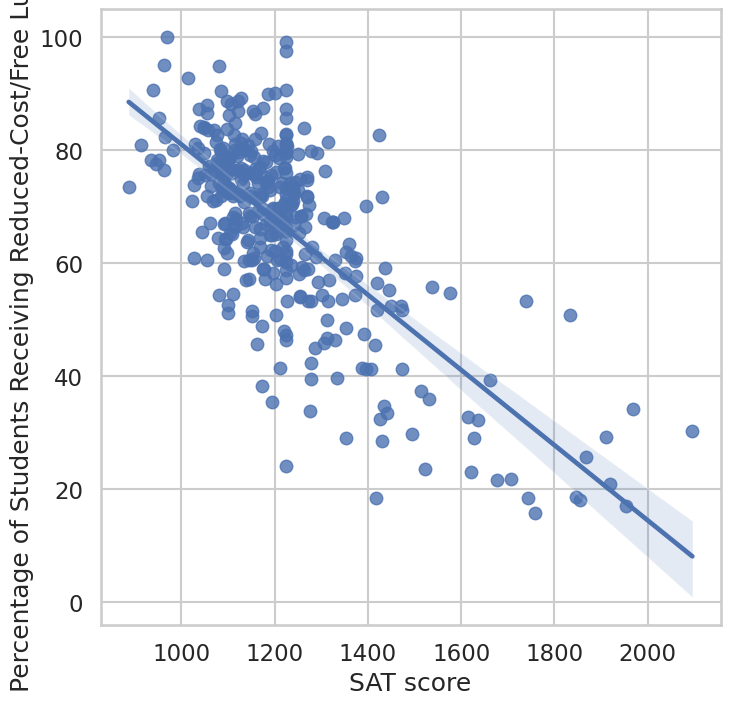

In [50]:
sns.set(style='whitegrid', context='talk')
plt.figure(figsize=(8,8))
sns.regplot(x='sat_score', y='frl_percent', data=combined)
plt.xlabel('SAT score')
plt.ylabel('Percentage of Students Receiving Reduced-Cost/Free Lunch')

Very clearly, the higher the percentage of students receiving financial aid for lunches has a clear and strong negative correlation with SAT score. The trend line slopes downward pretty steeply.

# Conclusion
There are a variety of factors that play into a school's average SAT scores. The common factor, however, is money. The schools with lower funding tend to have fewer AP classes which means they have fewer students studying for college preparedness. Schools with higher percentages of ESL students spend more of their budget focusing on teaching English to their foreign language students. And most prominently: schools with higher percentages of students receiving lunch assistance have lower SAT scores on average. 

Money talks louder than any other factor. Students of poverty must spend larger portions of their time outside of school dedicated to survival and must overcome larger hurdles put in place by socioeconomic disadvantage. Examples of poverty-induced hurdles:
- Many high school students in poverty have to work to help with bills/rent/etc, [which can negatively impact their schoolwork, if the family is already in poverty.](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2936460/)
- Have to help with chores around the house while their parents/guardians work second or even third jobs.
- Have to rely on [reduced nutrients and cognition due to diet.](http://www.ascd.org/publications/educational-leadership/may13/vol70/num08/How-Poverty-Affects-Classroom-Engagement.aspx)
- Employed parents in poverty are least likely to get [access to the support infrastructures their children need.](https://files.eric.ed.gov/fulltext/EJ1029033.pdf)
- Poor students tend to [live in poorer regions with under-funded schools](https://www.irp.wisc.edu/publications/focus/pdfs/foc332e.pdf)
- Under-funded schools [tend to lack the funding for advanced classes](https://www.gao.gov/products/GAO-19-8) which lead to lower levels of college preparedness.